## Choix des données 

J’ai choisi ce dataset car il traite d’un problème réel et stratégique : la décision d’octroi de crédit. Il permet d’étudier un problème de classification binaire dans un contexte financier, avec des données hétérogènes (numériques et catégorielles) et des valeurs manquantes. Cela en fait un cas d’étude pertinent pour mettre en œuvre un pipeline complet de machine learning et analyser les facteurs influençant la décision.

# Importations des données

In [9]:
import pandas as pd

file_path = "crx.data"  # adapte si besoin

df = pd.read_csv(file_path, header=None, na_values="?")

df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,+


In [13]:
df.columns = [f"A{i}" for i in range(1, 17)]
df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,+


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      678 non-null    object 
 1   A2      678 non-null    float64
 2   A3      690 non-null    float64
 3   A4      684 non-null    object 
 4   A5      684 non-null    object 
 5   A6      681 non-null    object 
 6   A7      681 non-null    object 
 7   A8      690 non-null    float64
 8   A9      690 non-null    object 
 9   A10     690 non-null    object 
 10  A11     690 non-null    int64  
 11  A12     690 non-null    object 
 12  A13     690 non-null    object 
 13  A14     677 non-null    float64
 14  A15     690 non-null    int64  
 15  A16     690 non-null    object 
dtypes: float64(4), int64(2), object(10)
memory usage: 86.4+ KB


In [12]:
df.describe()

,1,2,7,10,13,14
count,678.000000,690.000000,690.000000,690.00000,677.000000,690.000000
mean,31.568171,4.758725,2.223406,2.40000,184.014771,1017.385507
std,11.957862,4.978163,3.346513,4.86294,173.806768,5210.102598
min,13.750000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,22.602500,1.000000,0.165000,0.00000,75.000000,0.000000
50%,28.460000,2.750000,1.000000,0.00000,160.000000,5.000000
75%,38.230000,7.207500,2.625000,3.00000,276.000000,395.500000
max,80.250000,28.000000,28.500000,67.00000,2000.000000,100000.000000


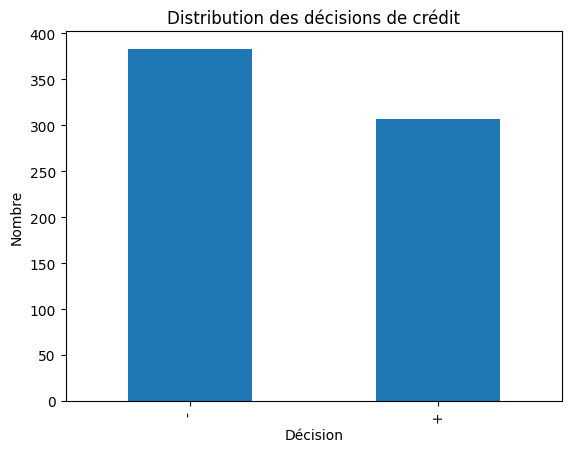

In [22]:
import matplotlib.pyplot as plt

df["A16"].value_counts().plot(kind="bar")
plt.title("Distribution des décisions de crédit")
plt.xlabel("Décision")
plt.ylabel("Nombre")
plt.show()

In [27]:
df["A16"].value_counts()

A16
-    383
+    307
Name: count, dtype: int64

### Commentaire  :
Le taux d'acceptation du crédit est de 44,49%

In [ ]:
#la moyenne selon l’acceptation
df.groupby("A16").mean(numeric_only=True)

,A2,A3,A8,A11,A14,A15
A16,,,,,,
+,33.720492,5.904951,3.427899,4.605863,164.421927,2038.859935
-,29.808231,3.839948,1.257924,0.631854,199.699468,198.605744


In [ ]:
#Analyse variable par variable
pd.crosstab(df["A1"], df["A16"], normalize="index") * 100

A16,+,-
A1,,
a,46.666667,53.333333
b,44.017094,55.982906


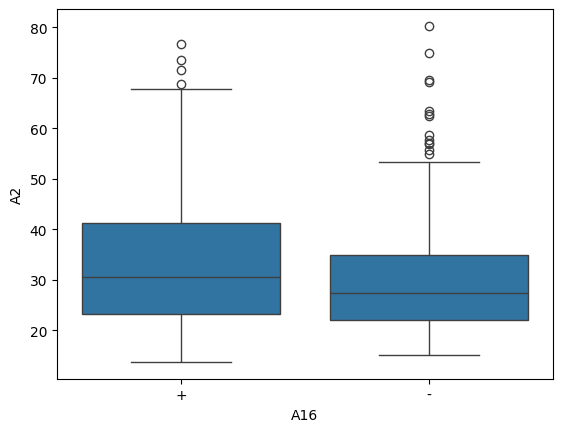

In [26]:
import seaborn as sns

sns.boxplot(x="A16", y="A2", data=df)
plt.show()

In [17]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]


In [ ]:
# Colonnes numériques
num_cols = X.select_dtypes(include=["float64", "int64"]).columns

# Colonnes catégorielles
cat_cols = X.select_dtypes(include="object").columns

# Remplissage
X[num_cols] = X[num_cols].fillna(X[num_cols].median()) # remplacer les valeurs manquantes par la médiane
X[cat_cols] = X[cat_cols].fillna(X[cat_cols].mode().iloc[0]) # remplacer les valeurs manquantes par le mode

In [19]:
#Encoder les variables catégorielles 
X = pd.get_dummies(X, drop_first=True)

In [20]:
# Transformer la variable cible en binaire 0 ou 1
y = y.map({"+": 1, "-": 0})

In [ ]:
#Vérifier 
y.value_counts()

A16
0    383
1    307
Name: count, dtype: int64

In [28]:
# Train / test  
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [29]:
# premier modèle on va faire du random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy : 0.8357487922705314
              precision    recall  f1-score   support

           0       0.85      0.84      0.84       110
           1       0.82      0.84      0.83        97

    accuracy                           0.84       207
   macro avg       0.84      0.84      0.84       207
weighted avg       0.84      0.84      0.84       207



On obtient une précision de 84% avec ce modèle. On regarde aussi le f1-score qui est aussi de 84% car il y a un fort déséquilibre entre les classes.

In [33]:
# deuxième modèle Xgboosting
# XGBoost
from xgboost import XGBClassifier
print("XGBOOST")
print("="*60)

model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

XGBOOST


/home/ndiaylam/miniforge3/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [10:50:04] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy : 0.8599033816425121
              precision    recall  f1-score   support

           0       0.87      0.86      0.87       110
           1       0.85      0.86      0.85        97

    accuracy                           0.86       207
   macro avg       0.86      0.86      0.86       207
weighted avg       0.86      0.86      0.86       207



On voit que le Xgboosting(avec une précision et un fi-score de 86%) et plus efficace que le random forest.